In [1]:
import numpy as np
import matplotlib.pyplot as plt

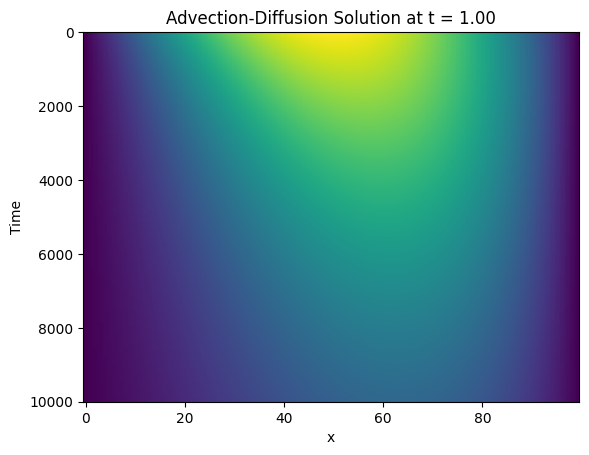

In [32]:
def advection_diffusion(u, C, D, dx):
    """
    Compute the new time derivative of the solution given the equation coefficients C, D and the current solution u.
    """
    # Compute the spatial derivatives with centered finite differences
    du_dx = (u[2:] - u[:-2]) / (2 * dx)  # First derivative
    du_dxx = (u[2:] - 2 *u[1:-1] + u[:-2]) / (dx ** 2)  # Second derivative

    # Compute the time derivative using the advection-diffusion equation
    du_dt = -C * du_dx + D * du_dxx
    
    return du_dt

# Generate u(x, 0)
dx = 0.01
x = np.arange(0, 1, dx)
u0 = np.sin(np.pi * x)
# Define coefficients
C = 0.3  # Advection coefficient
D = 0.1  # Diffusion coefficient
# define time propagation parameters
t_final = 1.0
dt = 0.0001
t_vet = np.arange(0, t_final + dt, dt)

# Enforcement of boundary conditions
u_matrix = np.zeros((int(t_final/dt) + 1, len(x)))
u_matrix[0, :] = u0
u_matrix[:, 0] = 0  # Boundary condition at x=0
u_matrix[:, -1] = 0  # Boundary condition at x=2

# Integration with forward Euler method
for (i, t) in enumerate(t_vet[1:]):
    du_dt = advection_diffusion(u_matrix[i, :], C, D, dx)
    u_matrix[i+1, 1:-1] = u_matrix[i, 1:-1] + du_dt * dt

# Plot the results on a heatmap to resemble 3d graph
plt.imshow(u_matrix, aspect='auto', cmap='viridis')
plt.xlabel('x')
plt.ylabel('Time')
plt.title('Advection-Diffusion Solution at t = {:.2f}'.format(t_final))
plt.show()